<a href="https://colab.research.google.com/github/adelinewidyatmoko/ProjectA_Kelompok6_BanjirArticles_PBA/blob/main/notebooks/04_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **POS Tagging**

In [40]:
# 1. Install Library
!pip install stanza tqdm pandas

# 2. Import Library
import pandas as pd
import stanza
from tqdm import tqdm

# Aktifkan progress bar
tqdm.pandas()

# 3. Load Dataset
print("Membaca dataset...")
df_sentimen_banjir = pd.read_csv('df_sentimen_banjir_processed.csv')
df_sentimen_bandang = pd.read_csv('df_sentimen_bandang_processed.csv')

# 4. Download dan Load Model Stanza Bahasa Indonesia
print("Mendownload dan menyiapkan model Stanza...")
stanza.download('id')
nlp_stanza = stanza.Pipeline('id', processors='tokenize,pos', use_gpu=True)

# 5. Fungsi POS Tagging Stanza
def pos_tagging_stanza(text):
    if isinstance(text, str) and text.strip() != "":
        # Memproses teks
        doc = nlp_stanza(text)
        result = []
        for sentence in doc.sentences:
            for word in sentence.words:
                result.append((word.text, word.upos))
        return result
    return []

# 6. Eksekusi POS Tagging
print("Memproses POS Tagging untuk data banjir biasa...")
df_sentimen_banjir['POS_Tags'] = df_sentimen_banjir['After_lemma'].progress_apply(pos_tagging_stanza)

print("Memproses POS Tagging untuk data banjir bandang...")
df_sentimen_bandang['POS_Tags'] = df_sentimen_bandang['After_lemma'].progress_apply(pos_tagging_stanza)

# 7. Simpan Hasil ke CSV Baru
print("Menyimpan hasil...")
df_sentimen_banjir.to_csv('hasil_pos_banjir_biasa.csv', index=False)
df_sentimen_bandang.to_csv('hasil_pos_banjir_bandang.csv', index=False)

print("\nProses selesai! File 'hasil_pos_banjir_biasa.csv' dan 'hasil_pos_banjir_bandang.csv' sudah tersimpan.")
display(df_sentimen_banjir[['After_lemma', 'POS_Tags']].head(3))

Membaca dataset...
Mendownload dan menyiapkan model Stanza...


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Downloading default packages for language: id (Indonesian) ...
INFO:stanza:File exists: /root/.cache/stanza/1.11.0/resources/id/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.11.0/resources
INFO:stanza:Checking for updates to resources.json in case models have been updated.  Note: this behavior can be turned off with download_method=None or download_method=DownloadMethod.REUSE_RESOURCES


INFO:stanza:Downloaded file to /root/.cache/stanza/1.11.0/resources/resources.json
INFO:stanza:Loading these models for language: id (Indonesian):
| Processor | Package    |
--------------------------
| tokenize  | gsd        |
| mwt       | gsd        |
| pos       | gsd_charlm |

INFO:stanza:Using device: cuda
INFO:stanza:Loading: tokenize
INFO:stanza:Loading: mwt
INFO:stanza:Loading: pos
INFO:stanza:Done loading processors!


Memproses POS Tagging untuk data banjir biasa...


100%|██████████| 511/511 [03:00<00:00,  2.84it/s]


Memproses POS Tagging untuk data banjir bandang...


100%|██████████| 974/974 [07:08<00:00,  2.27it/s]


Menyimpan hasil...

Proses selesai! File 'hasil_pos_banjir_biasa.csv' dan 'hasil_pos_banjir_bandang.csv' sudah tersimpan.


,After_lemma,POS_Tags
0,wali kota makasar munafri api arifudin tetap s...,"[(wali, NOUN), (kota, NOUN), (makasar, NOUN), ..."
1,jumlah ruas jalan kota makasar sulawesi selata...,"[(jumlah, NOUN), (ruas, NOUN), (jalan, NOUN), ..."
2,badan penangulangan bencana daerah bpbd makasa...,"[(badan, NOUN), (penangulangan, NOUN), (bencan..."


**Visualisasi POS Tagging**

In [41]:
import ast
from IPython.display import HTML, display

def visualize_pos_tags_highlight(pos_data, max_tokens=150):
    if isinstance(pos_data, str):
        try:
            pos_list = ast.literal_eval(pos_data)
        except:
            return "<p>Gagal membaca format data.</p>"
    else:
        pos_list = pos_data

    if not isinstance(pos_list, list):
        return "<p>Data tidak tersedia.</p>"

    pos_list = pos_list[:max_tokens]

    color_map = {
        'NN': '#e2f0cb', 'NOUN': '#e2f0cb', 'NND': '#e2f0cb',
        'NNP': '#cce3f6', 'PROPN': '#cce3f6',
        'VB': '#ffdfd3', 'VERB': '#ffdfd3',
        'JJ': '#fdfd96', 'ADJ': '#fdfd96',
        'RB': '#c5eaee', 'ADV': '#c5eaee',
        'CD': '#ffb347', 'OD': '#ffb347', 'NUM': '#ffb347',
        'PR': '#e2d9f3', 'PRP': '#e2d9f3', 'PRON': '#e2d9f3',
        'IN': '#f0f0f0', 'ADP': '#f0f0f0',
        'CC': '#f0f0f0', 'SC': '#f0f0f0', 'CCONJ': '#f0f0f0', 'SCONJ': '#f0f0f0'
    }

    html_content = ""
    for word, tag in pos_list:
        # Hapus spasi dan jadikan huruf besar agar cocok dengan color_map
        clean_tag = tag.strip().upper()
        bg_color = color_map.get(clean_tag, '#ffffff')

        html_content += f"""
        <span style="background-color: {bg_color}; border: 1px solid #bbb; border-radius: 4px; padding: 2px 6px; margin: 3px; display: inline-block; font-family: sans-serif; box-shadow: 1px 1px 2px rgba(0,0,0,0.05);">
            <span style="font-weight: bold; color: #000; font-size: 14px;">{word}</span>
            <span style="font-size: 10px; font-weight: 800; color: #444; margin-left: 3px;">[{clean_tag}]</span>
        </span>
        """
    return html_content

In [42]:
sample_index = 0

# Menggunakan dataframe 'df_sentimen_banjir' dan kolom 'POS_Tags'
html_pos = visualize_pos_tags_highlight(
    df_sentimen_banjir.loc[sample_index, 'POS_Tags'],
    max_tokens=150
)

display(HTML(f"""
<h3>POS Tagging Visualization</h3>
<div style="line-height:2.1; font-size:15px; padding:10px; background-color:#2b2b2b; border-radius:8px;">
{html_pos}
</div>
"""))

## **Named Entity Recognition (NER)**

In [43]:
# 1. Install Library
!pip install transformers tqdm pandas

# 2. Import Library
import pandas as pd
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
from tqdm import tqdm

# Aktifkan progress bar pandas
tqdm.pandas()

# 3. Load Dataset Berita
print("Membaca dataset berita...")
df_berita = pd.read_csv('data_berita_banjir_scraped.csv')

# Tangani baris yang kosong (NaN) di kolom 'Konten' agar tidak error saat diproses
df_berita['Konten'] = df_berita['Konten'].fillna("").astype(str)

# 4. Inisialisasi Model IndoBERT
print("Memuat model NER IndoBERT...")
model_name = "cahya/bert-base-indonesian-NER"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForTokenClassification.from_pretrained(model_name)

ner_pipeline = pipeline("ner", model=model, tokenizer=tokenizer, aggregation_strategy="simple")

# 5. Fungsi Ekstraksi NER dengan Chunking
# (Sangat penting untuk menghindari error batas maksimal token dari model BERT)
def extract_entities_chunked(text, chunk_size=300):
    chunks = [text[i:i+chunk_size] for i in range(0, len(text), chunk_size)]
    results = []

    for chunk in chunks:
        try:
            ents = ner_pipeline(chunk)
            results.extend([(ent['word'], ent['entity_group']) for ent in ents])
        except Exception as e:
            continue

    return results

# 6. Eksekusi Ekstraksi NER
print("Mulai mengekstrak entitas NER pada kolom 'Konten'...")
# Catatan: Karena menggunakan deep learning, proses ini mungkin memakan waktu.
# GPU (T4) yang kamu aktifkan sebelumnya akan sangat membantu mempercepat proses ini.
df_berita['entities'] = df_berita['Konten'].progress_apply(extract_entities_chunked)

# 7. Format Menjadi Dataframe Detail untuk Analisis
print("Menyusun ulang format data...")
rows = []
for idx, row in df_berita.iterrows():
    if isinstance(row['entities'], list):
        for text, ent_type in row['entities']:
            rows.append({
                'id_berita': idx,
                'entitas': text,
                'label': ent_type
            })

df_ner_detail = pd.DataFrame(rows)

# 8. Simpan Hasil ke CSV Baru
print("Menyimpan hasil ekstraksi NER...")
df_ner_detail.to_csv('hasil_ner_berita.csv', index=False)

print("\nProses selesai! File 'hasil_ner_berita.csv' sudah tersimpan.")
display(df_ner_detail.head(10))

Membaca dataset berita...
Memuat model NER IndoBERT...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForTokenClassification LOAD REPORT from: cahya/bert-base-indonesian-NER
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.pooler.dense.bias       | UNEXPECTED |  | 
bert.pooler.dense.weight     | UNEXPECTED |  | 
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Mulai mengekstrak entitas NER pada kolom 'Konten'...


100%|██████████| 2454/2454 [03:00<00:00, 13.57it/s]


Menyusun ulang format data...
Menyimpan hasil ekstraksi NER...

Proses selesai! File 'hasil_ner_berita.csv' sudah tersimpan.


,id_berita,entitas,label
0,3,wali kota makassar,NOR
1,3,munafri ' appi ' arifuddin,PER
2,3,kelurahan katimbang,GPE
3,3,paccerakkang,GPE
4,3,kecamatan biringkanaya,GPE
5,3,kota makassar,GPE
6,3,app,PER
7,3,##i,ORG
8,3,kantor balai kota makassar,LOC
9,3,senin ( 12 / 1 / 2026 ),DAT


**Visualisasi NER**

In [44]:
# Load file hasil NER
df_ner = pd.read_csv('hasil_ner_berita.csv')

id_berita_pilihan = 3

# Filter data hanya untuk ID berita tersebut
df_sample = df_ner[df_ner['id_berita'] == id_berita_pilihan]

if df_sample.empty:
    html_ner = f"<p style='color: white;'>Tidak ada entitas yang ditemukan pada ID berita {id_berita_pilihan}. Silakan coba angka/ID lain.</p>"
else:
    # Ubah format kolom dataframe menjadi list of tuples
    ner_tuples = list(zip(df_sample['entitas'], df_sample['label']))

    # Buat HTML-nya
    html_ner = visualize_ner_tags_highlight(ner_tuples, max_tokens=150)

# Tampilkan ke layar
display(HTML(f"""
<h3>Visualisasi Hasil NER (Berita ID: {id_berita_pilihan})</h3>
<div style="line-height:2.1; font-size:15px; padding:15px; background-color:#2b2b2b; border-radius:8px;">
{html_ner}
</div>
"""))

**N-Grams**

In [45]:
import pandas as pd
import nltk
from nltk.util import ngrams
from collections import Counter
import matplotlib.pyplot as plt
import seaborn as sns

# Download resource pendukung
nltk.download('punkt')

def get_top_ngrams(corpus, n=None, top_k=15):
    """Fungsi untuk mengekstrak n-grams dari kolom After_lemma"""
    words = " ".join(corpus.astype(str)).split()
    n_grams = ngrams(words, n)
    counts = Counter(n_grams)
    return counts.most_common(top_k)

def plot_ngrams(ngram_data, title, color_palette='magma'):
    """Fungsi untuk visualisasi grafik batang"""
    if not ngram_data:
        return
    labels = [" ".join(item[0]) for item in ngram_data]
    counts = [item[1] for item in ngram_data]

    plt.figure(figsize=(10, 7))
    sns.barplot(x=counts, y=labels, hue=labels, palette=color_palette, legend=False)
    plt.title(title, fontsize=15, fontweight='bold')
    plt.xlabel('Frekuensi Muncul')
    plt.ylabel('Kata/Frasa')
    plt.grid(axis='x', linestyle='--', alpha=0.6)
    plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Memproses Unigrams...


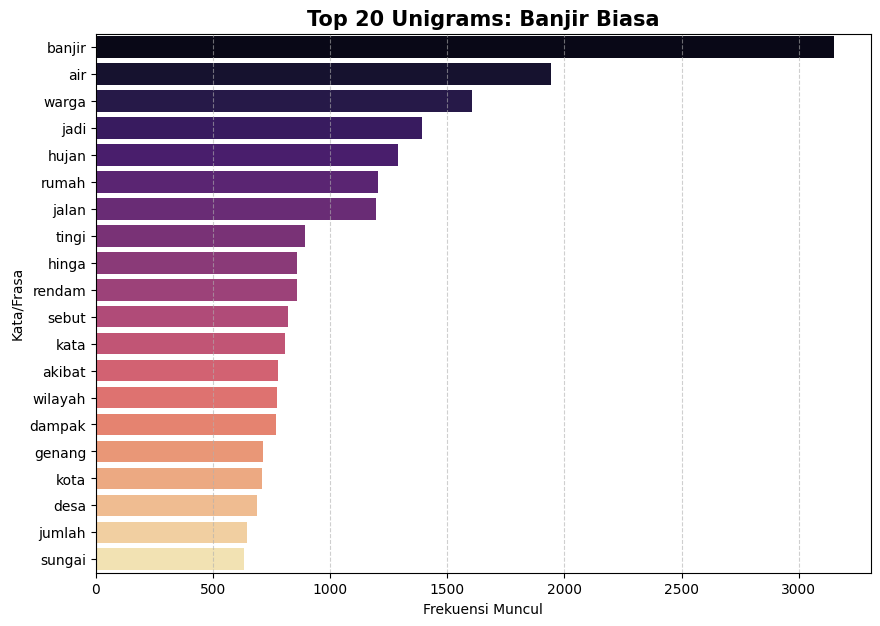

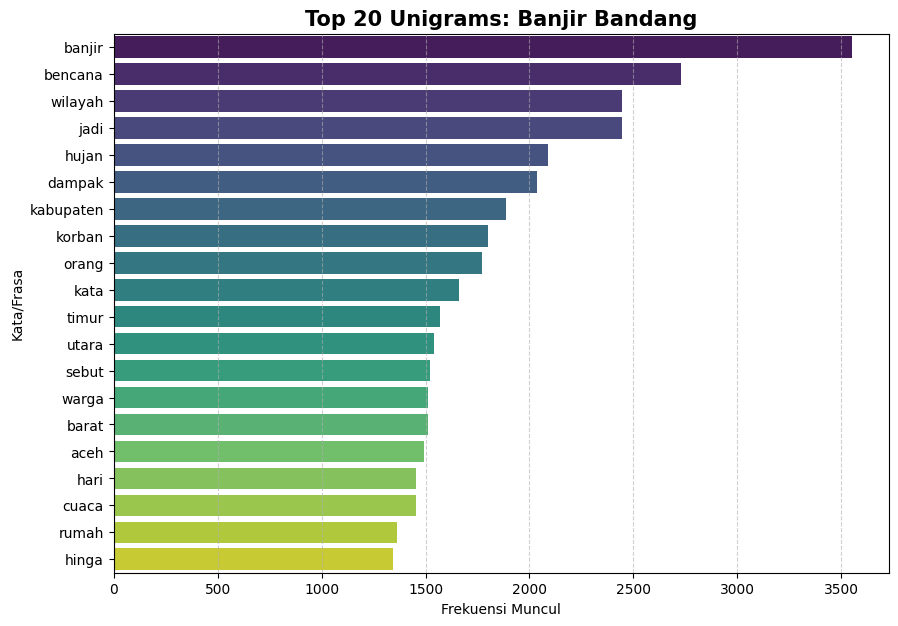

In [46]:
print("Memproses Unigrams...")

# Visualisasi untuk Banjir Biasa menggunakan kolom After_lemma
top_1_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=1, top_k=20)
plot_ngrams(top_1_biasa, "Top 20 Unigrams: Banjir Biasa", 'magma')

# Visualisasi untuk Banjir Bandang menggunakan kolom After_lemma
top_1_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=1, top_k=20)
plot_ngrams(top_1_bandang, "Top 20 Unigrams: Banjir Bandang", 'viridis')

Memproses Bigrams...


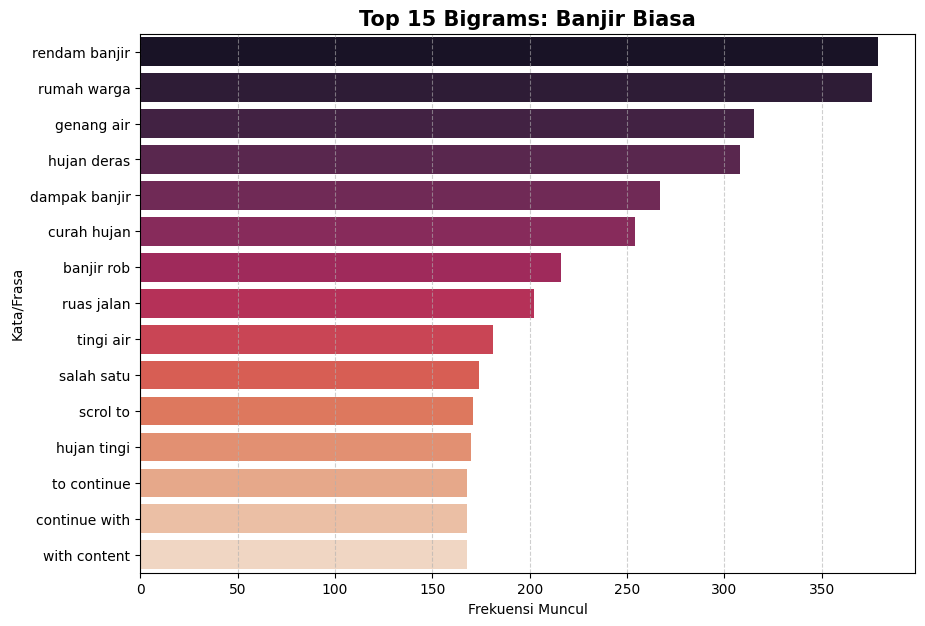

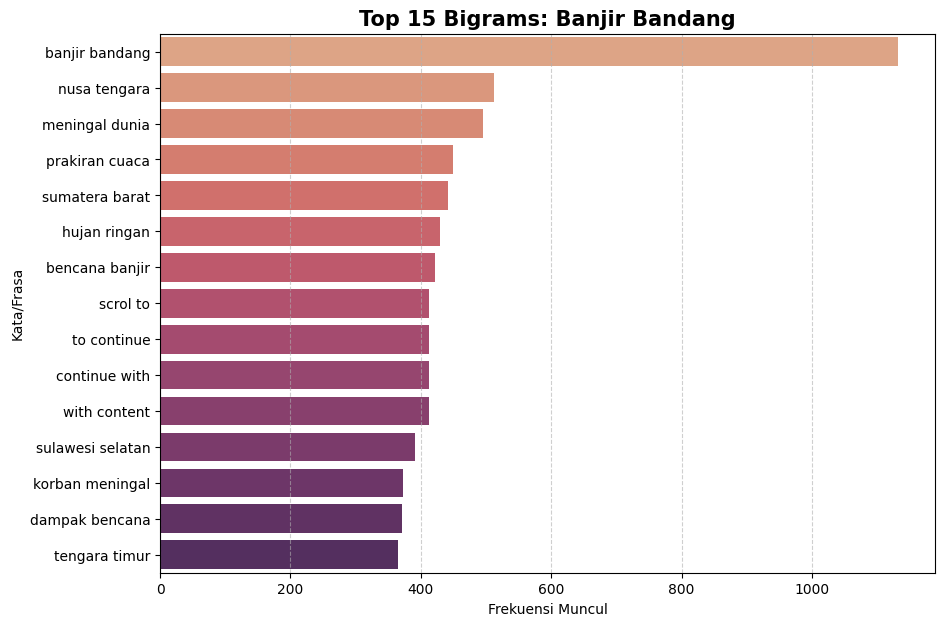

In [47]:
print("Memproses Bigrams...")

# Visualisasi untuk Banjir Biasa[cite: 1]
top_2_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=2, top_k=15)
plot_ngrams(top_2_biasa, "Top 15 Bigrams: Banjir Biasa", 'rocket')

# Visualisasi untuk Banjir Bandang[cite: 1]
top_2_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=2, top_k=15)
plot_ngrams(top_2_bandang, "Top 15 Bigrams: Banjir Bandang", 'flare')

Memproses Trigrams...


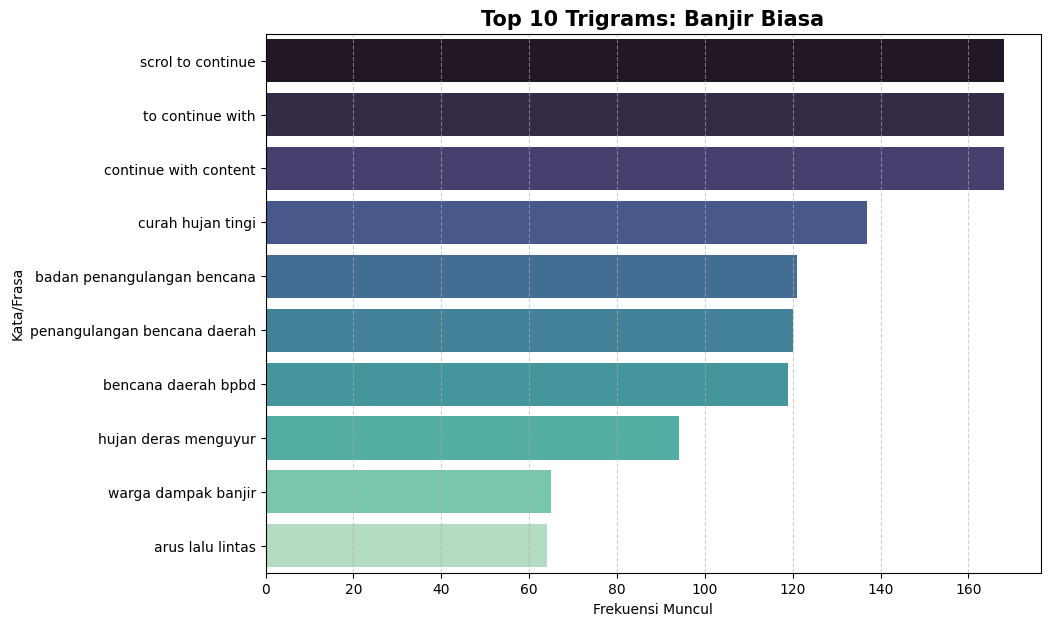

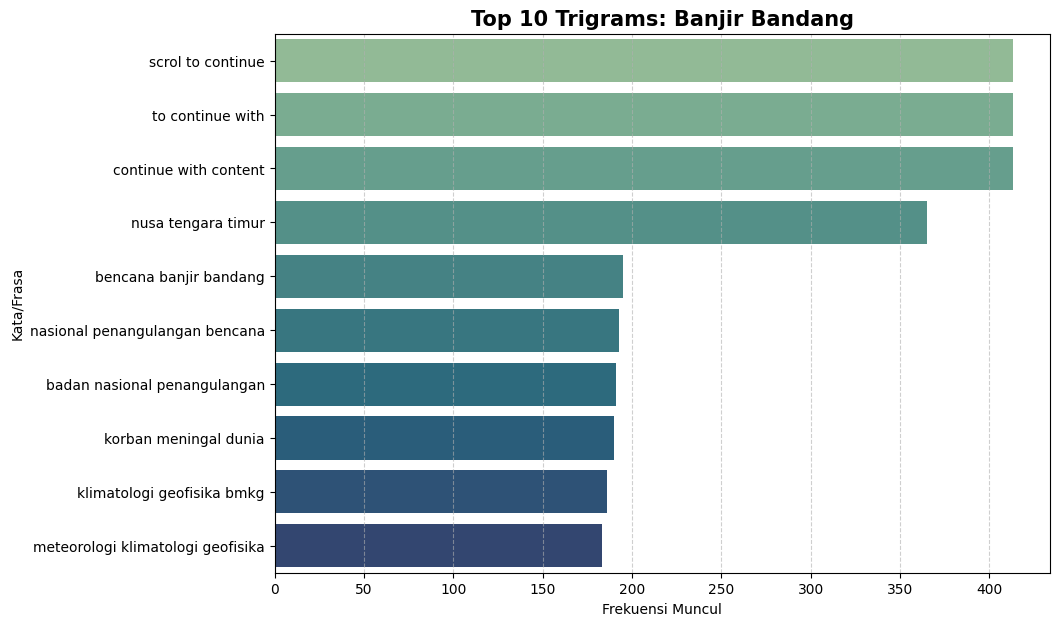

In [48]:
print("Memproses Trigrams...")

# Visualisasi untuk Banjir Biasa[cite: 1]
top_3_biasa = get_top_ngrams(df_sentimen_banjir['After_lemma'], n=3, top_k=10)
plot_ngrams(top_3_biasa, "Top 10 Trigrams: Banjir Biasa", 'mako')

# Visualisasi untuk Banjir Bandang[cite: 1]
top_3_bandang = get_top_ngrams(df_sentimen_bandang['After_lemma'], n=3, top_k=10)
plot_ngrams(top_3_bandang, "Top 10 Trigrams: Banjir Bandang", 'crest')